In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from os.path import join
from tqdm import tqdm
import pytorch_lightning as pl

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/SS-HSU_benchmark")

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [17]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.standardise(utils.oneD_to_2d(Y_flat))
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

if dataset != "urban":
    Y_init, A_init = rsfm.reshape_Y("DOFA", Y_init, 224, A_init)
else:
    Y_init = F.interpolate(Y_init, size=(224, 224))
    A_init = F.interpolate(A_init, size=(224, 224))
H = Y_init.shape[-1]

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]
    
fm_name = "SpecAware"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3012.08it/s]


In [18]:
import torchvision.transforms as T
from omegaconf import DictConfig
from omegaconf import OmegaConf
from pytorch_lightning import Trainer
from pytorch_lightning import seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from torchvision.transforms import InterpolationMode
from os.path import join

from featup.datasets.JitteredImage import apply_jitter, sample_transform
from featup.datasets.util import get_dataset, SingleImageDataset
from featup.downsamplers import SimpleDownsampler, AttentionDownsampler
from featup.featurizers.util import get_featurizer
from featup.layers import ChannelNorm
from featup.losses import TVLoss, SampledCRFLoss, entropy
from featup.upsamplers import get_upsampler
from featup.util import pca, RollingAvg, unnorm, norm, prep_image

class ScaleNet(torch.nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.net = torch.nn.Conv2d(dim, 1, 1)
        with torch.no_grad():
            self.net.weight.copy_(self.net.weight * .1)
            self.net.bias.copy_(self.net.bias * .1)

    def forward(self, x):
        return torch.exp(self.net(x) + .1).clamp_min(.0001)

class JBUFeatUp(pl.LightningModule):
    def __init__(self, n_jitters, max_pad, max_zoom,
                 kernel_size, final_size, lr, random_projection, predicted_uncertainty,
                 crf_weight, filter_ent_weight, tv_weight, upsampler, downsampler, chkpt_dir, input_size=224, B=3):
        super().__init__()
        self.n_jitters = n_jitters
        self.max_pad = max_pad
        self.max_zoom = max_zoom
        self.kernel_size = kernel_size
        self.final_size = final_size
        self.lr = lr
        self.random_projection = random_projection
        self.predicted_uncertainty = predicted_uncertainty
        self.crf_weight = crf_weight
        self.filter_ent_weight = filter_ent_weight
        self.tv_weight = tv_weight
        self.chkpt_dir = chkpt_dir
        self.input_size = input_size
        
        self.model, self.dim = fm, D
        self.model = self.model.to(dev)

        for p in self.model.parameters():
            p.requires_grad = False
        self.model = torch.nn.Sequential(self.model, ChannelNorm(self.dim))
        self.upsampler = get_upsampler(upsampler, self.dim, B=B)

        self.downsampler = AttentionDownsampler(self.dim, self.kernel_size, self.final_size, blur_attn=True)

        self.scale_net = ScaleNet(self.dim)

        self.avg = RollingAvg(20)

        self.crf = SampledCRFLoss(alpha=.1, beta=.15, gamma=.005, w1=10.0, w2=3.0, shift=0.00, n_samples=1000)
        self.tv = TVLoss()

        self.automatic_optimization = False

    def forward(self, x):
        _, feat = rsfm.extract_f(fm, x, self.input_size, wavelengths)
        feats = utils.oneD_to_2d(feat).unsqueeze(0)
        return self.upsampler(feats, x)

    def project(self, feats, proj):
        if proj is None:
            return feats
        else:
            return torch.einsum("bchw,bcd->bdhw", feats, proj)

    def training_step(self, batch, batch_idx):
        opt = self.optimizers()
        opt.zero_grad()

        with torch.no_grad():
            if type(batch) == dict:
                img = batch['img']
            else:
                img, _ = batch
            _, feat = rsfm.extract_f(fm, img, self.input_size, wavelengths)
            lr_feats = utils.oneD_to_2d(feat).unsqueeze(0)

        full_rec_loss = 0.0
        full_crf_loss = 0.0
        full_entropy_loss = 0.0
        full_tv_loss = 0.0
        full_total_loss = 0.0
        for i in range(self.n_jitters):
            hr_feats = self.upsampler(lr_feats, img)

            if hr_feats.shape[2] != img.shape[2]:
                hr_feats = torch.nn.functional.interpolate(hr_feats, img.shape[2:], mode="bilinear")

            with torch.no_grad():
                transform_params = sample_transform(
                    True, self.max_pad, self.max_zoom, img.shape[2], img.shape[3])
                jit_img = apply_jitter(img, self.max_pad, transform_params)

                _, feat = rsfm.extract_f(fm, jit_img, self.input_size, wavelengths)
                lr_jit_feats = utils.oneD_to_2d(feat).unsqueeze(0)

            proj = torch.randn(lr_feats.shape[0],
                                lr_feats.shape[1],
                                self.random_projection, device=lr_feats.device)
            proj /= proj.square().sum(1, keepdim=True).sqrt()

            hr_jit_feats = apply_jitter(hr_feats, self.max_pad, transform_params)
            proj_hr_feats = self.project(hr_jit_feats, proj)

            down_jit_feats = self.project(self.downsampler(hr_jit_feats, jit_img), proj)

            scales = self.scale_net(lr_jit_feats)
            scale_factor = (1 / (2 * scales ** 2))
            mse = (down_jit_feats - self.project(lr_jit_feats, proj)).square()
            rec_loss = (scale_factor * mse + scales.log()).mean() / self.n_jitters

            full_rec_loss += rec_loss.item()

            if self.crf_weight > 0 and i == 0:
                crf_loss = self.crf(img, proj_hr_feats)
                full_crf_loss += crf_loss.item()
            else:
                crf_loss = 0.0

            if self.filter_ent_weight > 0.0:
                entropy_loss = entropy(self.downsampler.get_kernel())
                full_entropy_loss += entropy_loss.item()
            else:
                entropy_loss = 0

            if self.tv_weight > 0 and i == 0:
                tv_loss = self.tv(proj_hr_feats.square().sum(1, keepdim=True))
                full_tv_loss += tv_loss.item()
            else:
                tv_loss = 0.0

            loss = rec_loss + self.crf_weight * crf_loss + self.tv_weight * tv_loss - self.filter_ent_weight * entropy_loss
            full_total_loss += loss.item()
            self.manual_backward(loss)

        self.avg.add("loss/crf", full_crf_loss)
        self.avg.add("loss/ent", full_entropy_loss)
        self.avg.add("loss/tv", full_tv_loss)
        self.avg.add("loss/rec", full_rec_loss)
        self.avg.add("loss/total", full_total_loss)

        if self.global_step % 100 == 0:
            self.trainer.save_checkpoint(self.chkpt_dir[:-5] + '/' + self.chkpt_dir[:-5] + f'_{self.global_step}.ckpt')

        if self.global_step < 10:
            self.clip_gradients(opt, gradient_clip_val=.0001, gradient_clip_algorithm="norm")

        opt.step()

        return None

    def validation_step(self, batch, batch_idx):
        with torch.no_grad():
            if self.trainer.is_global_zero and batch_idx == 0:

                if type(batch) == dict:
                    img = batch['img']
                else:
                    img, _ = batch
                _, feat = rsfm.extract_f(fm, img, self.input_size, wavelengths)
                lr_feats = utils.oneD_to_2d(feat).unsqueeze(0)

                hr_feats = self.upsampler(lr_feats, img)

                if hr_feats.shape[2] != img.shape[2]:
                    hr_feats = torch.nn.functional.interpolate(hr_feats, img.shape[2:], mode="bilinear")

                transform_params = sample_transform(
                    True, self.max_pad, self.max_zoom, img.shape[2], img.shape[3])
                jit_img = apply_jitter(img, self.max_pad, transform_params)

                _, feat = rsfm.extract_f(fm, jit_img, self.input_size, wavelengths)
                lr_jit_feats = utils.oneD_to_2d(feat).unsqueeze(0)

                proj = torch.randn(lr_feats.shape[0],
                                    lr_feats.shape[1],
                                    self.random_projection, device=lr_feats.device)
                proj /= proj.square().sum(1, keepdim=True).sqrt()

                scales = self.scale_net(lr_jit_feats)

                hr_jit_feats = apply_jitter(hr_feats, self.max_pad, transform_params)
                down_jit_feats = self.downsampler(hr_jit_feats, jit_img)

                [red_lr_feats], fit_pca = pca([lr_feats[0].unsqueeze(0)])
                [red_hr_feats], _ = pca([hr_feats[0].unsqueeze(0)], fit_pca=fit_pca)
                [red_lr_jit_feats], _ = pca([lr_jit_feats[0].unsqueeze(0)], fit_pca=fit_pca)
                [red_hr_jit_feats], _ = pca([hr_jit_feats[0].unsqueeze(0)], fit_pca=fit_pca)
                [red_down_jit_feats], _ = pca([down_jit_feats[0].unsqueeze(0)], fit_pca=fit_pca)

    def configure_optimizers(self):
        all_params = []
        all_params.extend(list(self.downsampler.parameters()))
        all_params.extend(list(self.upsampler.parameters()))

        all_params.extend(list(self.scale_net.parameters()))

        return torch.optim.NAdam(all_params, lr=self.lr)


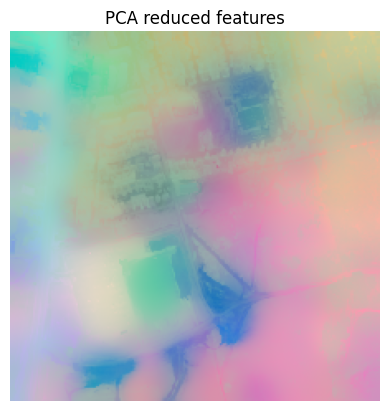

In [19]:
final_size = alpha
kernel_size = new_H//alpha
name = (f"jbu_stack_"
        f"{dataset}_attention_"
        f"crf_0.001_tv_0.0"
        f"_ent_0.0")

log_dir = join(f"{global_path}/FeatUp", f"logs/jbu/{name}")
chkpt_dir = join(f"{global_path}/FeatUp", f"checkpoints/jbu/{name}.ckpt")
model = JBUFeatUp(n_jitters=5, max_pad=20, 
    max_zoom=2, kernel_size=kernel_size, final_size=final_size, lr=1e-3, random_projection=30, 
    predicted_uncertainty=True, crf_weight=0.001, filter_ent_weight=0.0, 
    tv_weight=0.0, upsampler="jbu_stack", downsampler="attention", chkpt_dir=chkpt_dir, input_size=H, B=B)

model.load_state_dict(torch.load(chkpt_dir)["state_dict"])
model = model.to(dev)
with torch.no_grad():
    up_feat = model(Y_init.to(dev))
plots.plot_pca_features(up_feat)

training 1/10
Current SAD = 0.558, NMSE = 0.946
training 2/10
Current SAD = 0.576, NMSE = 0.952
training 3/10
Current SAD = 0.549, NMSE = 0.769
training 4/10
Current SAD = 0.533, NMSE = 0.834
training 5/10
Current SAD = 0.538, NMSE = 0.916
training 6/10
Current SAD = 0.547, NMSE = 1.110
training 7/10
Current SAD = 0.560, NMSE = 0.977
training 8/10
Current SAD = 0.593, NMSE = 0.860
training 9/10
Current SAD = 0.569, NMSE = 1.050
training 10/10
Current SAD = 0.564, NMSE = 0.944
Average SAD = 0.559 ± 0.02, NMSE = 0.936 ± 0.10


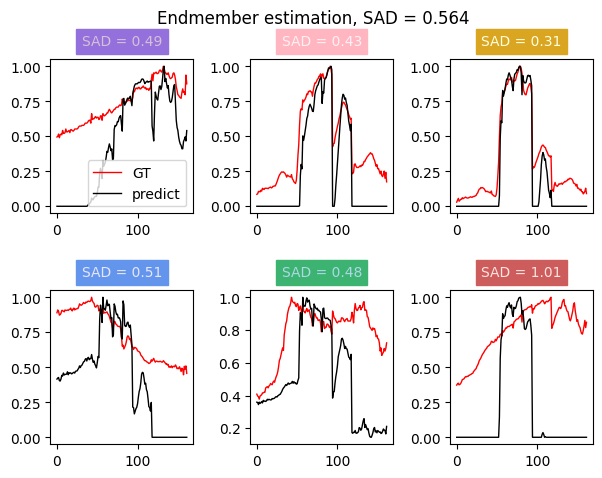

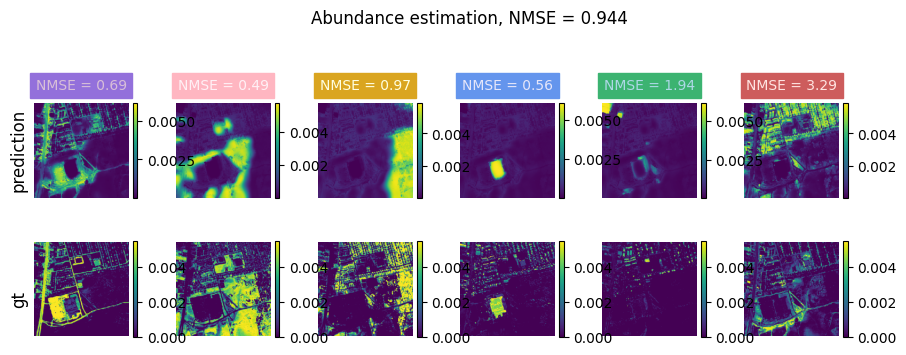

In [ ]:
n_xp = 10
mses, sads = [], []

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromUpFeat(D=D, H=H, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.18)

    for _ in range(epochs):
    
        optimizer.zero_grad()

        E_hat, A_hat, Y_hat = model(up_feat)

        loss = model.loss(Y_init, Y_hat, A_hat, E_hat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        E_hat, A_hat, _ = model(up_feat)

        if i < n_xp-1:
            sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        else:
            sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init, E_init, normalise_E=True, normalise_A=True, return_results=True)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")